In [28]:
# Educational Data Analysis with Python

## Model Evaluation

In [29]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("../datasets/Education_Student_Depression_Cleaned.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0


In [31]:
#Encode

encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = encoder.fit_transform(df[column])

In [32]:
#Split

X = df.drop("Depression", axis=1)

y = df["Depression"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
#Train

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
#Predict

predictions = model.predict(X_test)

In [35]:
#Accuracy

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7568536104640745


In [36]:
#Classification report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.71      0.72      0.71      2343
           1       0.80      0.78      0.79      3238

    accuracy                           0.76      5581
   macro avg       0.75      0.75      0.75      5581
weighted avg       0.76      0.76      0.76      5581



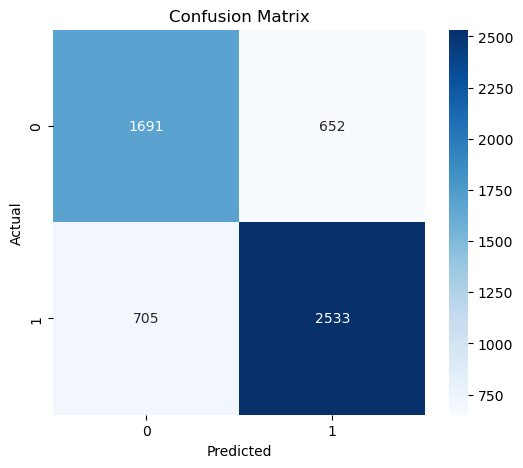

In [37]:
#confusion matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
#Observation

#The Decision Tree model achieved an accuracy of 75.69% on the test dataset. The confusion matrix and classification report show that the model correctly classified most of the instances, with a balanced performance across both classes. The evaluation metrics indicate that the model performs reasonably well in predicting student depression, though there is still room for improvement.